# Exploratory Data Analysis

**Plan 2 - Tasks 5, 6 & 7**

Univariate analysis, bivariate analysis & correlation, and outlier detection on the behavioral feature-engineered dataset.

## Task 5: Univariate Analysis

### Load Feature-Engineered Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../datasets/student_exam_features.csv')
print(f'Loaded: {df.shape}')

Loaded: (10000, 35)


### Numeric Feature Distributions

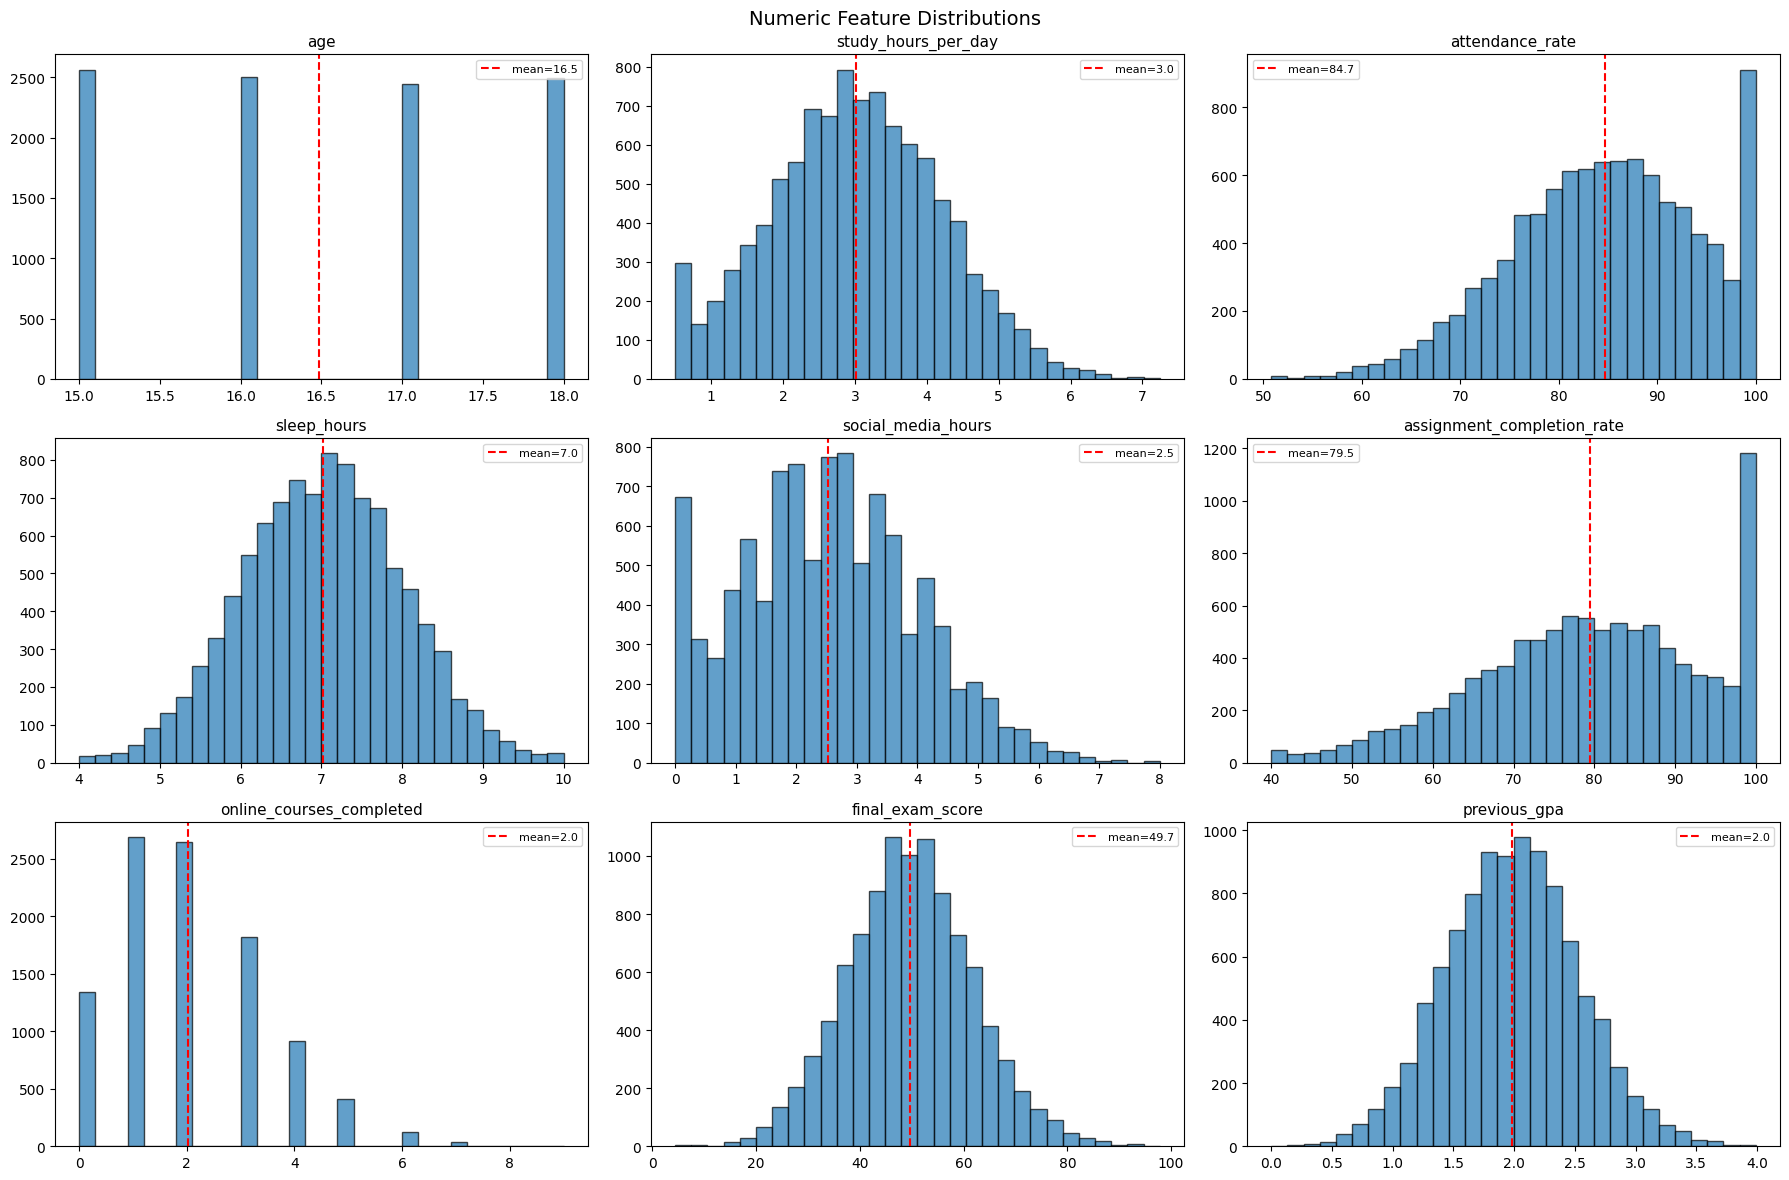

In [2]:
numeric_cols = ['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours',
                'social_media_hours', 'assignment_completion_rate',
                'online_courses_completed', 'final_exam_score', 'previous_gpa']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=8)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical Feature Distributions

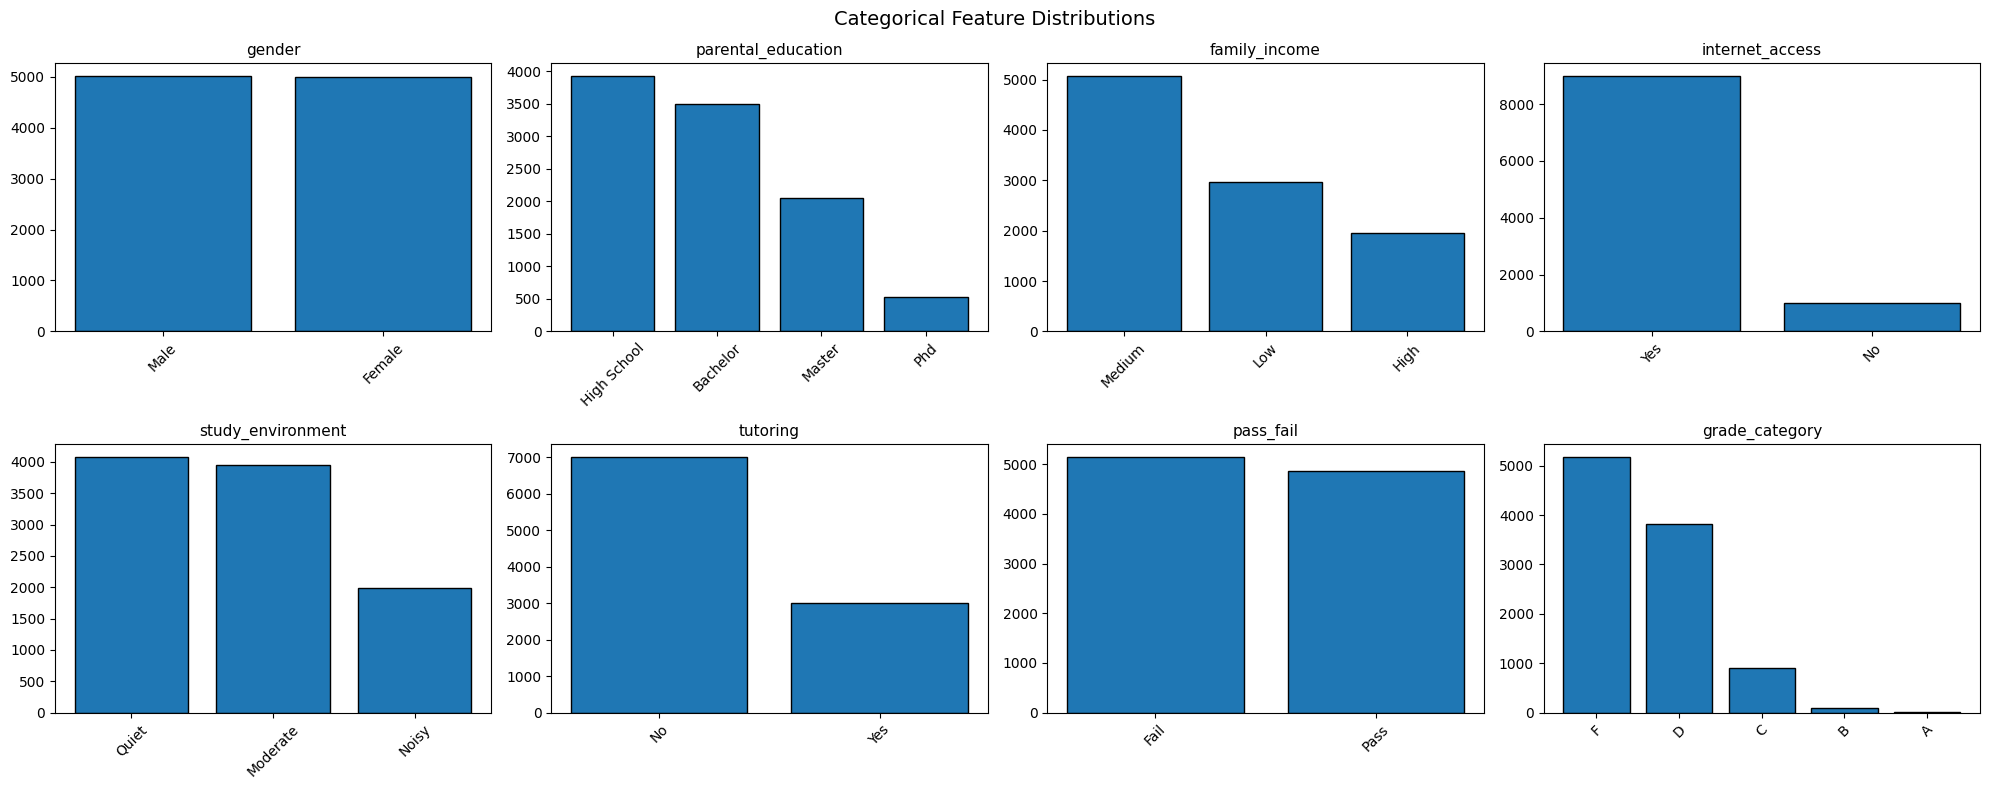

In [3]:
categorical_cols = ['gender', 'parental_education', 'family_income',
                    'internet_access', 'study_environment', 'tutoring',
                    'pass_fail', 'grade_category']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, edgecolor='black')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/02_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 6: Bivariate Analysis and Correlation

### Correlation Matrix

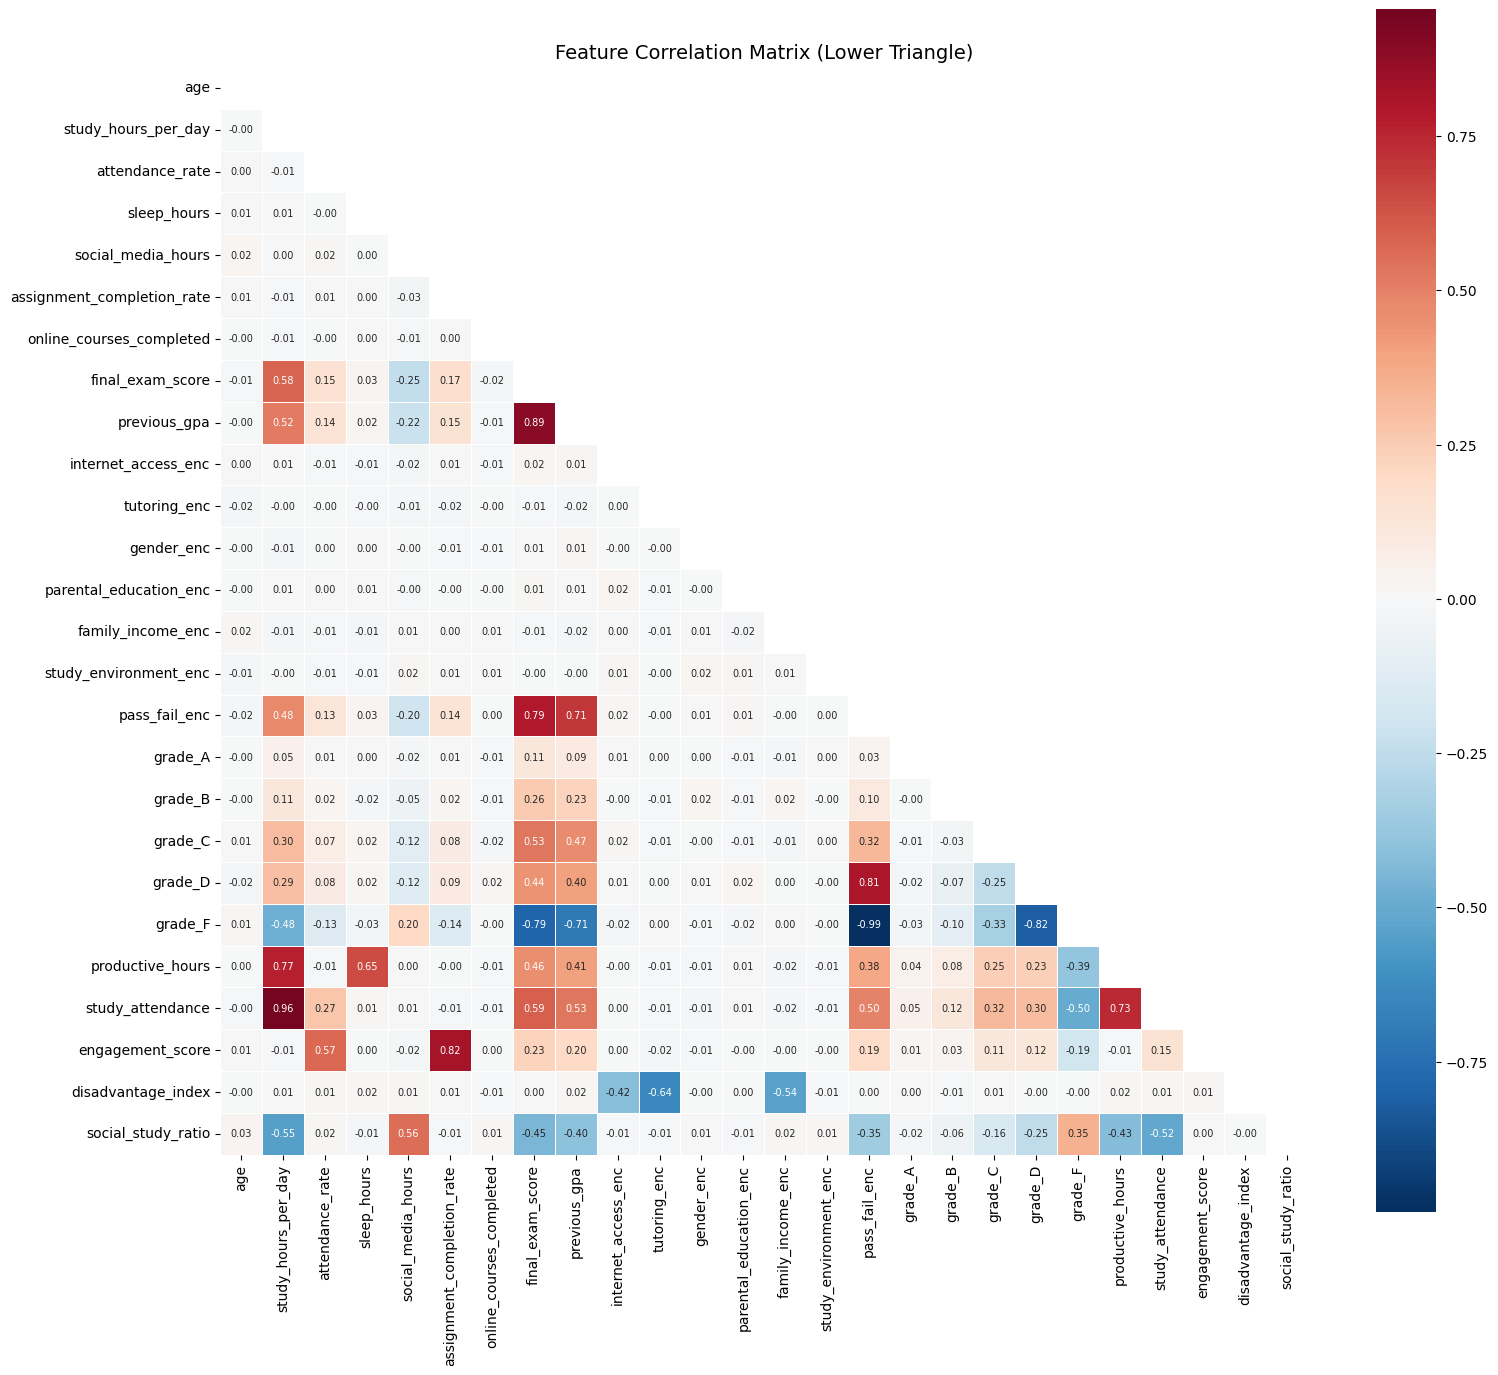

In [4]:
numeric_df = df.select_dtypes(include='number').drop(columns=['student_id'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Top Correlations with Final Exam Score

In [5]:
target_corr = corr['final_exam_score'].drop('final_exam_score').sort_values(key=abs, ascending=False)
print('Top 10 correlations with final_exam_score:')
print(target_corr.head(10))

Top 10 correlations with final_exam_score:
previous_gpa           0.891239
pass_fail_enc          0.792398
grade_F               -0.792391
study_attendance       0.591358
study_hours_per_day    0.575822
grade_C                0.533982
productive_hours       0.456292
social_study_ratio    -0.449124
grade_D                0.443401
grade_B                0.258231
Name: final_exam_score, dtype: float64


### Scatter Plots - Top 5 Correlated Features

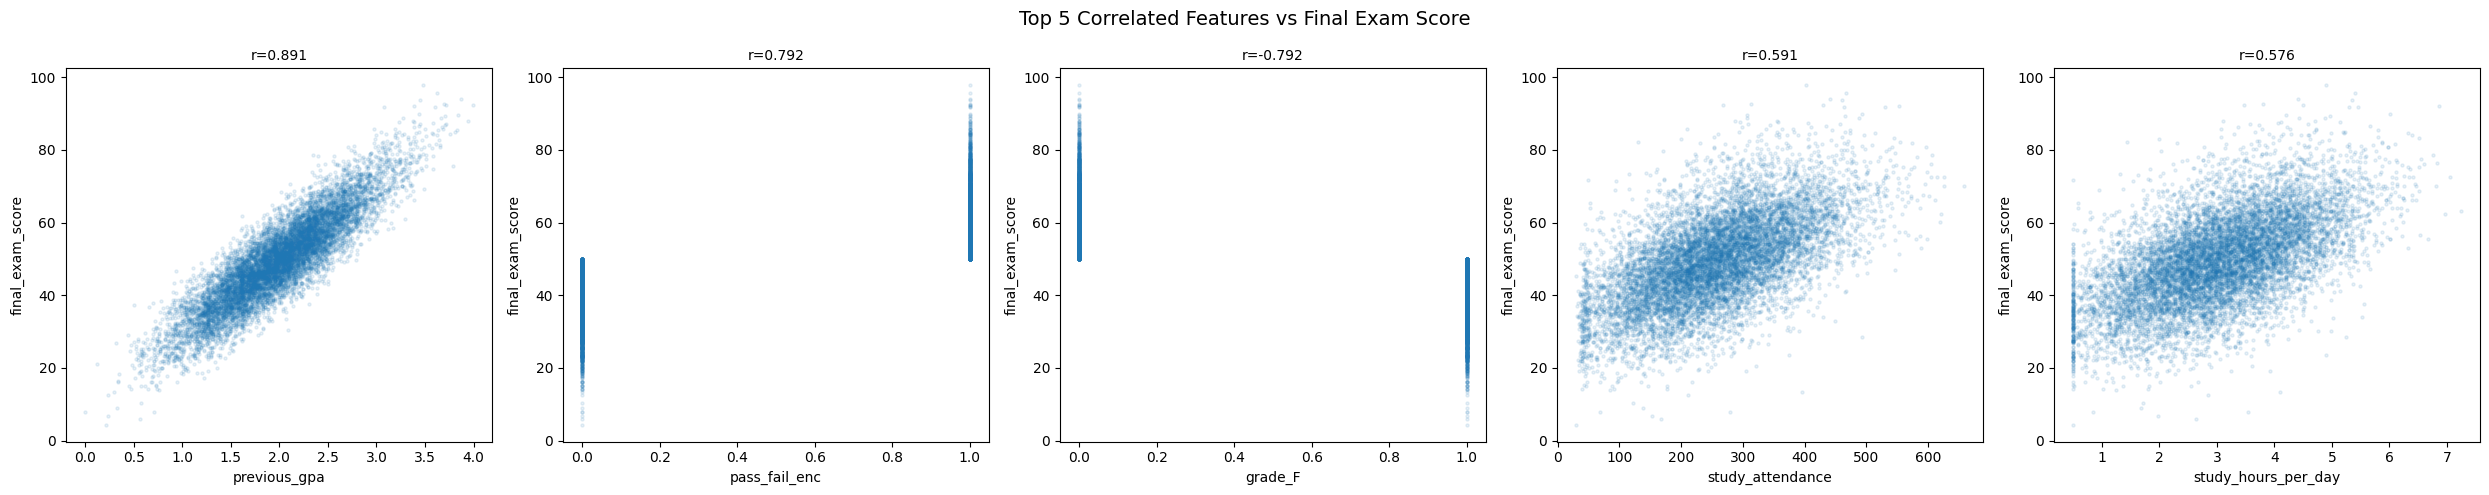

In [6]:
top5 = target_corr.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, col in enumerate(top5):
    axes[i].scatter(df[col], df['final_exam_score'], alpha=0.1, s=5)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('final_exam_score', fontsize=10)
    axes[i].set_title(f'r={target_corr[col]:.3f}', fontsize=10)
plt.suptitle('Top 5 Correlated Features vs Final Exam Score', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/04_top_correlations_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Exam Score by Categorical Groups

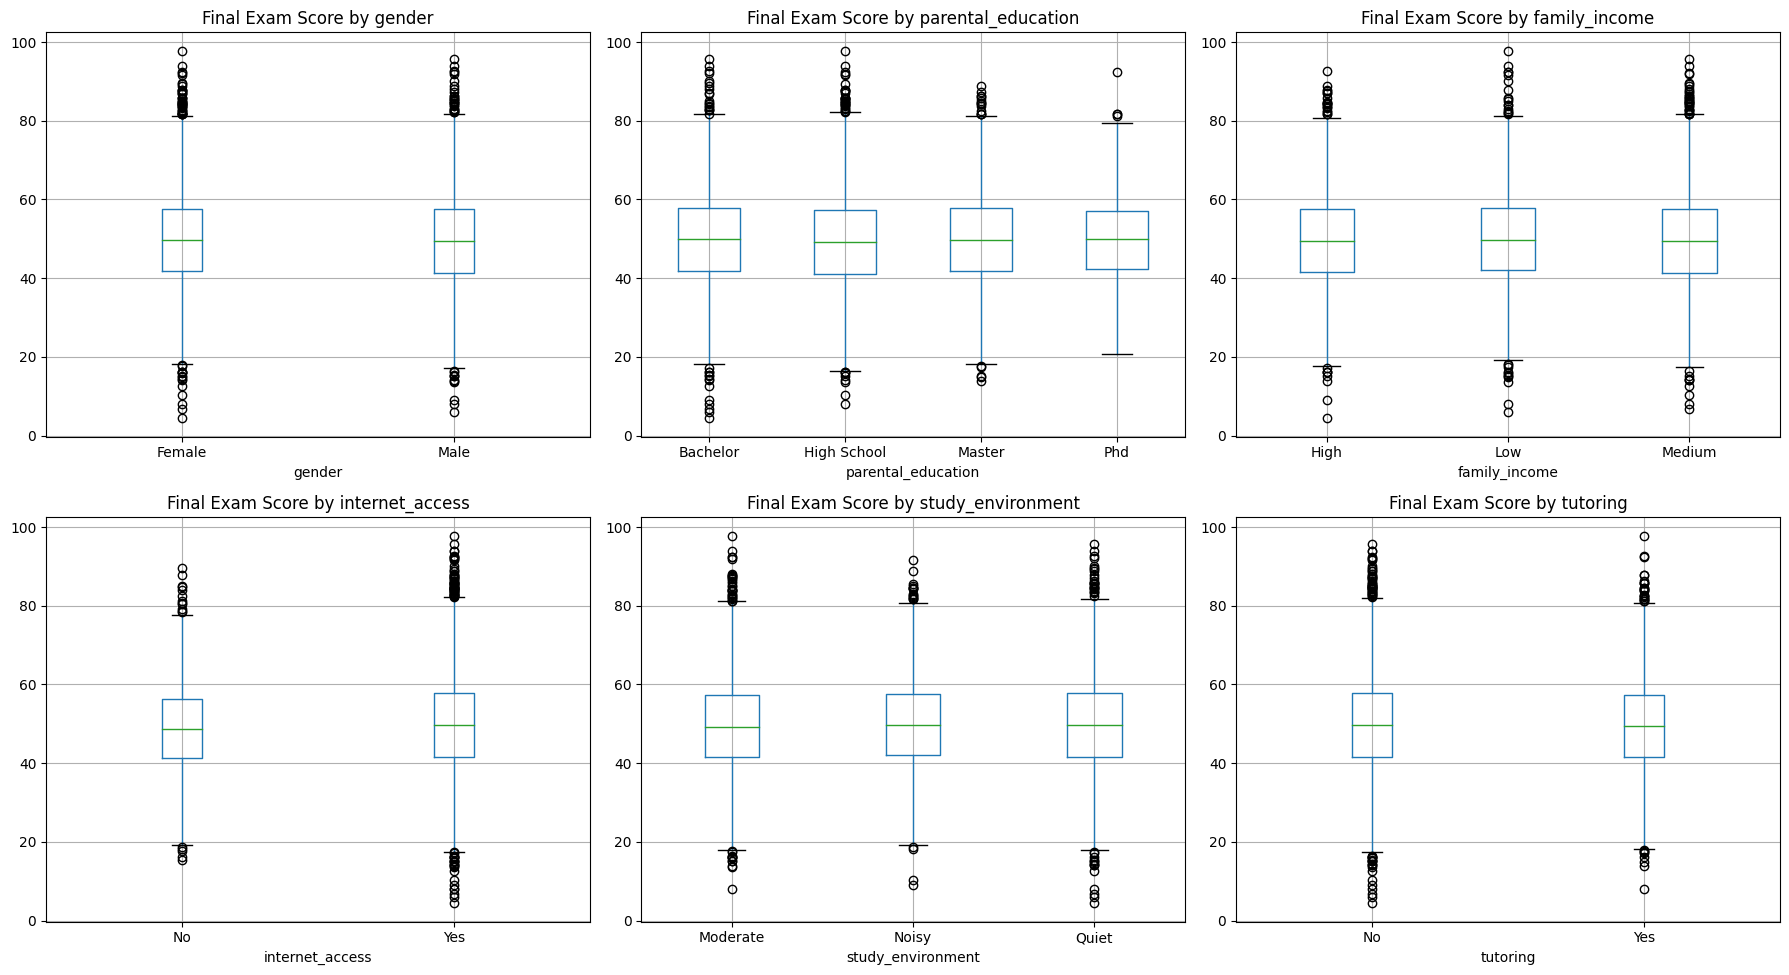

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
group_cols = ['gender', 'parental_education', 'family_income',
              'internet_access', 'study_environment', 'tutoring']
for i, col in enumerate(group_cols):
    row, col_idx = divmod(i, 3)
    df.boxplot(column='final_exam_score', by=col, ax=axes[row][col_idx])
    axes[row][col_idx].set_title(f'Final Exam Score by {col}')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../deliverables/figures/05_scores_by_groups.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 7: Outlier Detection

### IQR Method

In [8]:
key_cols = ['study_hours_per_day', 'attendance_rate', 'sleep_hours',
            'social_media_hours', 'final_exam_score', 'previous_gpa']
outlier_summary = {}
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    print(f'{col}: {n_outliers} outliers (range: [{lower:.2f}, {upper:.2f}])')

study_hours_per_day: 27 outliers (range: [-0.24, 6.28])
attendance_rate: 36 outliers (range: [57.84, 112.34])
sleep_hours: 63 outliers (range: [4.31, 9.72])
social_media_hours: 36 outliers (range: [-1.50, 6.50])
final_exam_score: 95 outliers (range: [17.60, 81.60])
previous_gpa: 62 outliers (range: [0.50, 3.46])


### Outlier Box Plots

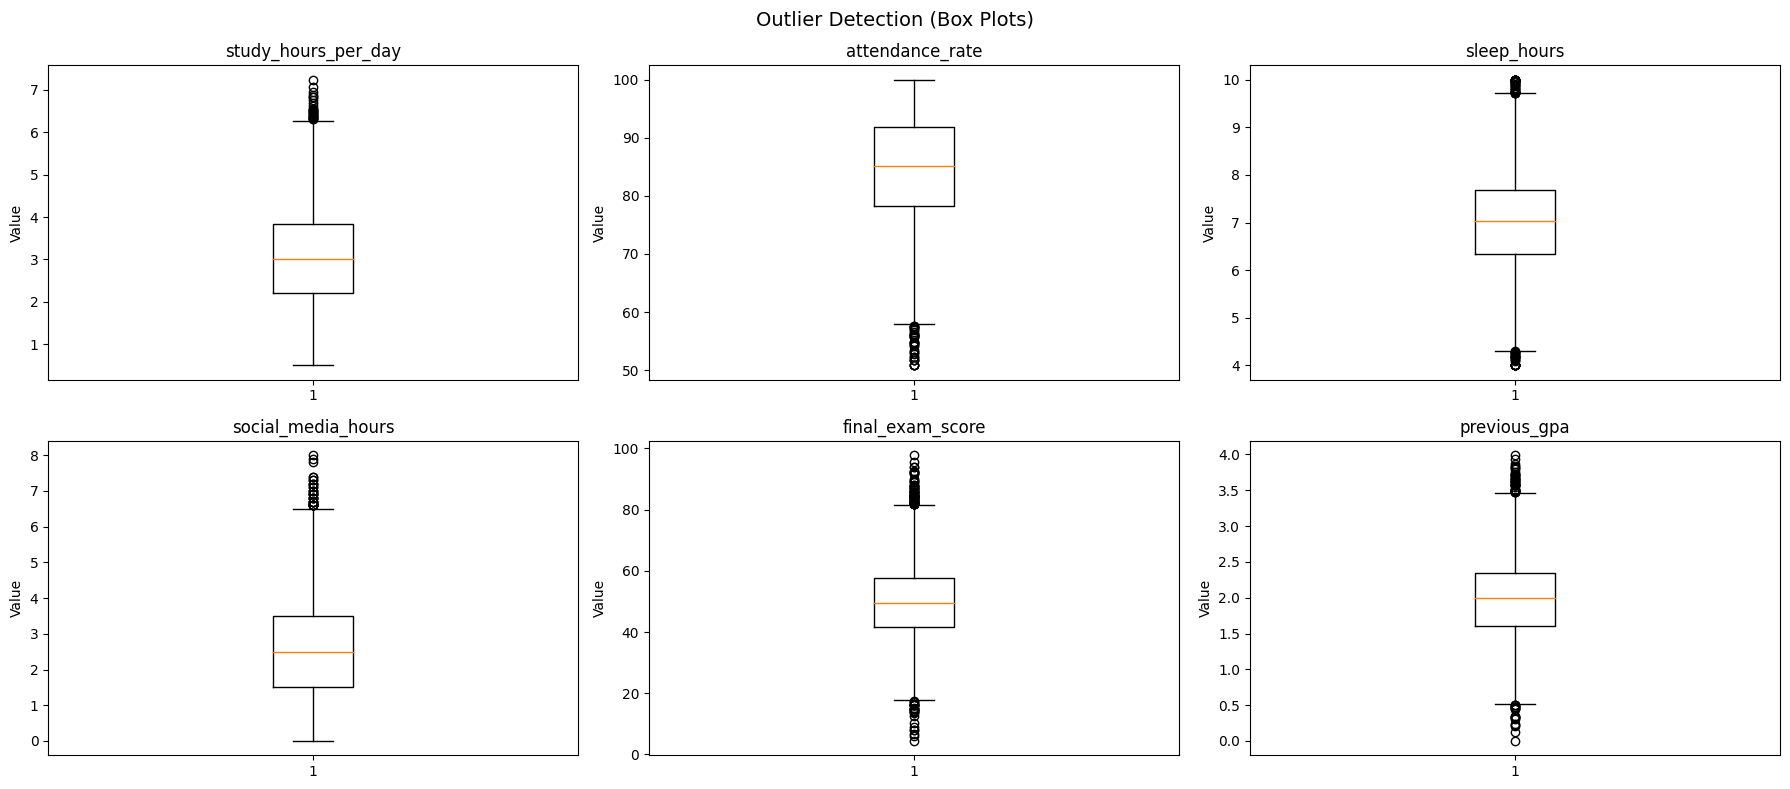

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
plt.suptitle('Outlier Detection (Box Plots)', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/06_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()